standard dev

Standardise = (x-mean)/Sd

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
#30 records
# data = {
#     'Age': np.random.randint(18, 70, size=30),
#     'Annual Income' : np.random.randint(20000, 150000, size=30),
#     'Spending Score' : np.random.randint(1, 101, size=30)
# }

# data = pd.DataFrame(data)
data = pd.read_csv('spending.csv')
data

,age,annual_income,spending_score
0,39,534000,61
1,42,1008000,64
2,34,830000,27
3,28,360000,45
4,27,1100000,51
...,...,...,...
114,26,360000,56
115,36,1100000,56
116,26,360000,56
117,36,1100000,56


In [3]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(data)

In [4]:
kmeans = KMeans(n_clusters=4,init="k-means++",max_iter=500,random_state=42)

In [5]:
kmeans.fit(x_scaled)

KMeans(max_iter=500, n_clusters=4, random_state=42)

In [6]:
data['Cluster'] = kmeans.labels_
data

,age,annual_income,spending_score,Cluster
0,39,534000,61,1
1,42,1008000,64,1
2,34,830000,27,0
3,28,360000,45,3
4,27,1100000,51,2
...,...,...,...,...
114,26,360000,56,3
115,36,1100000,56,1
116,26,360000,56,3
117,36,1100000,56,1


In [7]:
kmeans.cluster_centers_

array([[-0.81535186, -0.9883286 , -1.08505294],
       [ 0.93814654,  0.91818423,  0.8204923 ],
       [-0.87850684,  1.16218044,  0.99842925],
       [-0.93724673, -0.97492294,  0.62828357]])

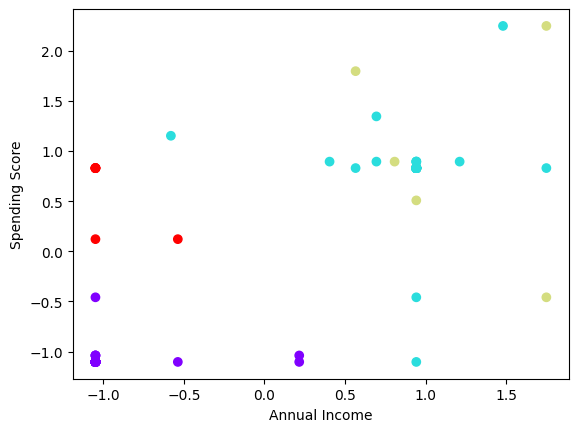

In [8]:
plt.scatter(x_scaled[:,1],x_scaled[:,2],c=kmeans.labels_,cmap='rainbow')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()